In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("SMSSpamCollection", sep="\t", names=["label","message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [6]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
df['label'] = df['label'].map({'ham':0,'spam':1})

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   label    0 non-null      float64
 1   message  5572 non-null   str    
dtypes: float64(1), str(1)
memory usage: 87.2 KB


In [22]:
import pandas as pd

df = pd.read_csv("SMSSpamCollection", sep="\t", names=["label","message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
df['label'].unique()

<StringArray>
['ham', 'spam']
Length: 2, dtype: str

In [24]:
df['label'] = df['label'].str.strip()

In [25]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

In [26]:
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Count")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Count")

plt.show()

In [3]:
import pandas as pd

df = pd.read_csv("SMSSpamCollection", sep="\t", names=["label","message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df['label'].unique()

<StringArray>
['ham', 'spam']
Length: 2, dtype: str

In [5]:
df['label'] = df['label'].str.strip()

In [6]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

In [7]:
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

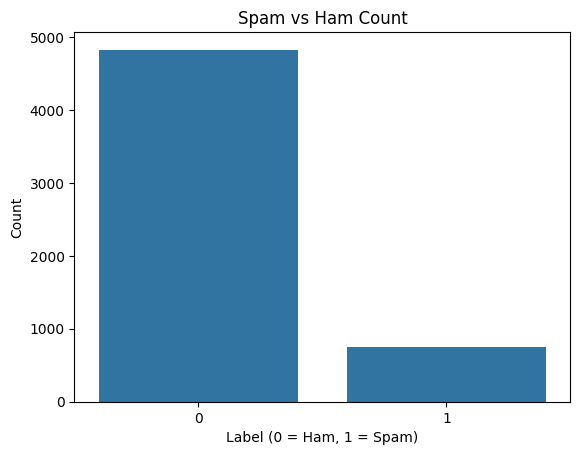

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Count")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Count")

plt.show()

In [12]:
import pandas as pd

df = pd.read_csv("SMSSpamCollection", sep='\t', names=['label','message'])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

In [14]:
df['label'].unique()

array([0, 1])

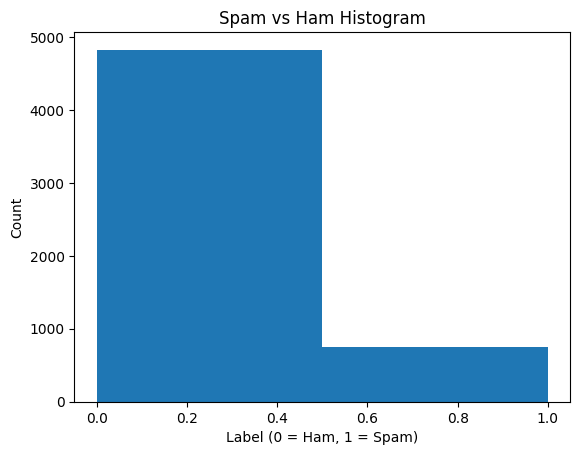

In [15]:
import matplotlib.pyplot as plt

plt.hist(df['label'], bins=2)
plt.title("Spam vs Ham Histogram")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Count")
plt.show()

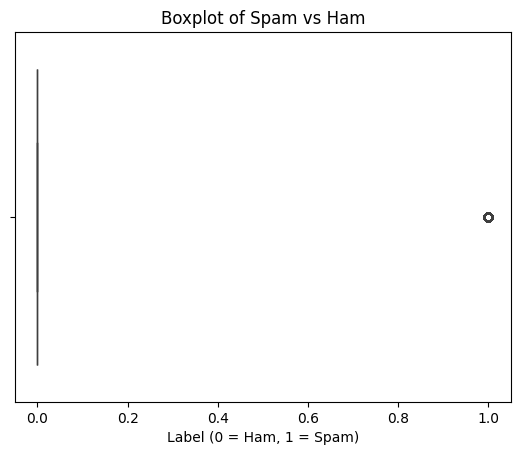

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['label'])
plt.title("Boxplot of Spam vs Ham")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.show()

In [17]:
df['length'] = df['message'].apply(len)
df.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


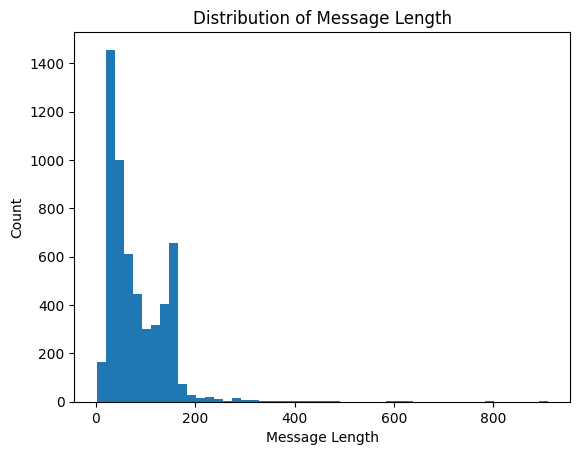

In [18]:
import matplotlib.pyplot as plt

plt.hist(df['length'], bins=50)
plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Count")
plt.show()

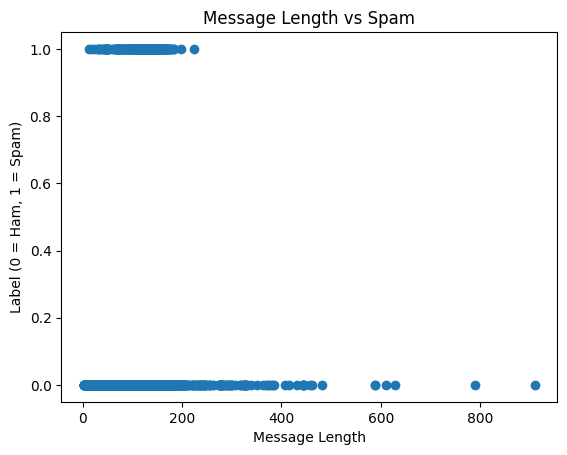

In [19]:
plt.scatter(df['length'], df['label'])
plt.title("Message Length vs Spam")
plt.xlabel("Message Length")
plt.ylabel("Label (0 = Ham, 1 = Spam)")
plt.show()

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['message'])
y = df['label']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

In [23]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier()
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, pred1))
print("Precision:", precision_score(y_test, pred1))
print("Recall:", recall_score(y_test, pred1))
print("F1 Score:", f1_score(y_test, pred1))

Logistic Regression Results
Accuracy: 0.9641255605381166
Precision: 1.0
Recall: 0.7315436241610739
F1 Score: 0.8449612403100775


In [25]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, pred2))
print("Precision:", precision_score(y_test, pred2))
print("Recall:", recall_score(y_test, pred2))
print("F1 Score:", f1_score(y_test, pred2))

Random Forest Results
Accuracy: 0.9811659192825112
Precision: 1.0
Recall: 0.8590604026845637
F1 Score: 0.924187725631769


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



In [27]:
from sklearn.metrics import roc_auc_score

prob1 = model1.predict_proba(X_test)[:,1]
roc1 = roc_auc_score(y_test, prob1)

print("ROC-AUC (Logistic Regression):", roc1)

ROC-AUC (Logistic Regression): 0.9882237692275626


In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model1, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.96233184 0.96233184 0.96050269 0.95691203 0.96319569]
Average CV Score: 0.9610548180112872
